In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('student_clustering.csv')

In [3]:
df.head()

,cgpa,iq
0,5.13,88
1,5.90,113
2,8.36,93
3,8.27,97
4,5.45,110


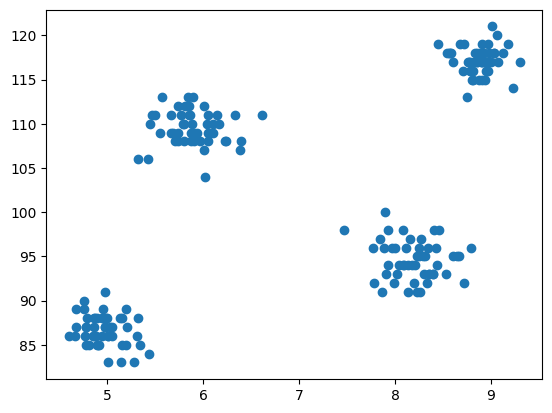

In [6]:
plt.scatter(df['cgpa'], df['iq'])
plt.show()

In [7]:
from sklearn.cluster import KMeans

In [8]:
wcss = []
for i in range (1, 11):
    km = KMeans(n_clusters=i)
    km.fit(df)
    wcss.append(km.inertia_)

In [9]:
wcss

[29957.898288,
 4184.14127,
 2364.0055834200834,
 681.96966,
 556.6603823704864,
 388.85240268759816,
 353.2966758136395,
 284.75905557901325,
 215.90054734920633,
 171.56716356743664]

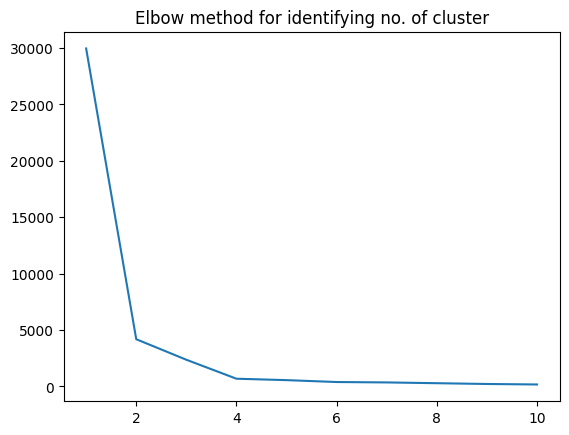

In [11]:
plt.plot(range(1, 11), wcss)
plt.title("Elbow method for identifying no. of cluster")
plt.show()

In [13]:
X = df.iloc[:, :].values
km = KMeans(n_clusters=4)

y_means = km.fit_predict(X)

In [17]:
X[y_means==0, 1]

array([88., 86., 88., 86., 87., 88., 87., 84., 85., 86., 83., 86., 87.,
       85., 83., 88., 85., 88., 86., 91., 86., 88., 89., 86., 90., 87.,
       87., 85., 87., 83., 86., 87., 85., 87., 87., 88., 88., 85., 86.,
       86., 86., 85., 88., 88., 89., 88., 88., 89., 85., 89.])

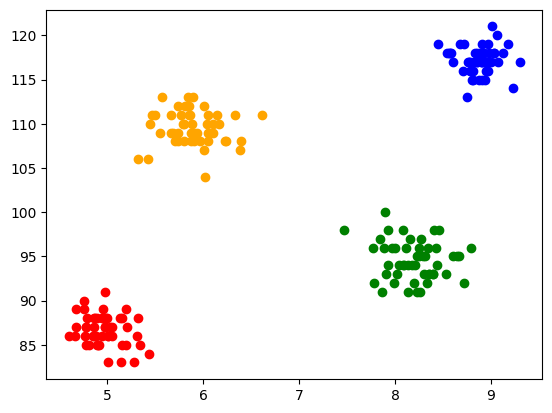

In [18]:
plt.scatter(X[y_means==0, 0], X[y_means==0, 1], color='red')
plt.scatter(X[y_means==1, 0], X[y_means==1, 1], color='blue')
plt.scatter(X[y_means==2, 0], X[y_means==2, 1], color='green')
plt.scatter(X[y_means==3, 0], X[y_means==3, 1], color='orange')
plt.show()

**k-means clustering on 3-D**

In [19]:
from sklearn.datasets import make_blobs

centroids = [(-5,-5,5),(5,5,-5),(3.5,-2.5,4),(-2.5,2.5,-4)]
cluster_std = [1,1,1,1]

X,y = make_blobs(n_samples=200,cluster_std=cluster_std,centers=centroids,n_features=3,random_state=1)

In [20]:
import plotly.express as px

In [21]:
fig = px.scatter_3d(x=X[:, 0], y=X[:, 1], z=X[:, 2])
fig.show()

In [22]:
wcss = []
for i in range(1, 16):
    km = KMeans(n_clusters=i)
    km.fit_predict(X)
    wcss.append(km.inertia_)

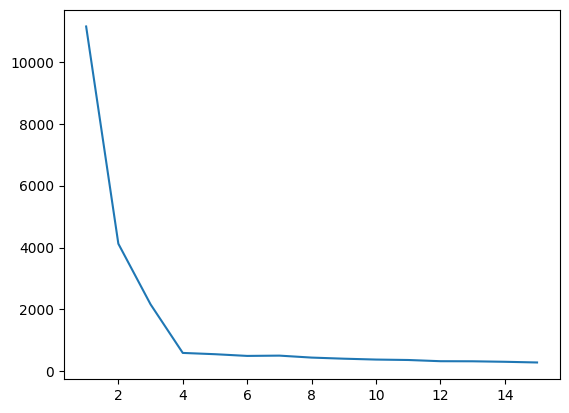

In [23]:
plt.plot(range(1, 16), wcss)
plt.show()

In [31]:
km = KMeans(n_clusters=4)
y_means = km.fit_predict(X)

In [32]:
df = pd.DataFrame()

In [33]:
df['col1'] = X[:, 0]
df['col2'] = X[:, 1]
df['col3'] = X[:, 2]
df['label'] = y

In [34]:
fig = px.scatter_3d(df, x='col1', y='col2', z='col3', color='label')
fig.show()